## ThinkDSP

This notebook contains code examples from Chapter 4: Noise

Copyright 2015 Allen Downey

License: [Creative Commons Attribution 4.0 International](http://creativecommons.org/licenses/by/4.0/)

In [5]:
# Get thinkdsp.py

import os
import sys

# if not os.path.exists('thinkdsp.py'):
#     !curl -O https://github.com/AllenDowney/ThinkDSP/raw/master/code/thinkdsp.py

sys.path.insert(0, os.path.abspath('../../third_party'))

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from thinkdsp import decorate

In [3]:
np.random.seed(17)

The simplest noise to generate is uncorrelated uniform (UU) noise:

In [4]:
from thinkdsp import UncorrelatedUniformNoise

signal = UncorrelatedUniformNoise()
wave = signal.make_wave(duration=0.5, framerate=11025)
wave.make_audio()

Here's what a segment of it looks like:

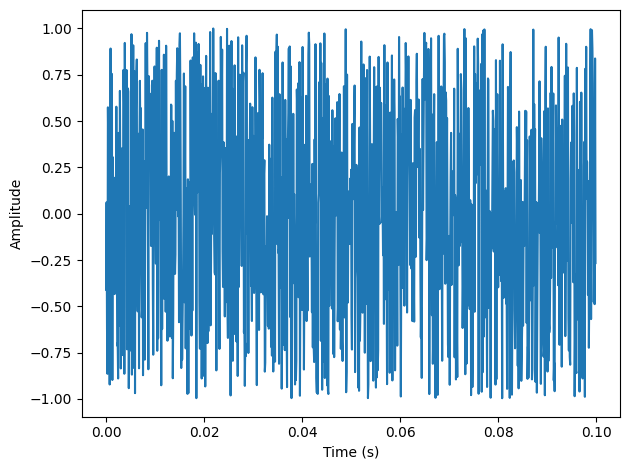

In [5]:
segment = wave.segment(duration=0.1)
segment.plot()
decorate(xlabel='Time (s)',
         ylabel='Amplitude')

And here's the spectrum:

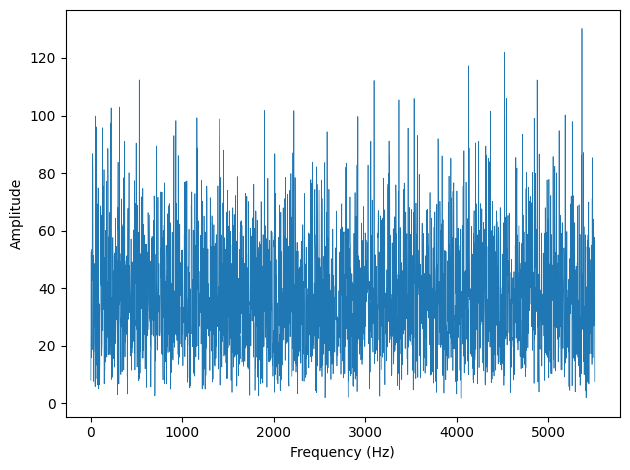

In [6]:
spectrum = wave.make_spectrum()
spectrum.plot(linewidth=0.5)
decorate(xlabel='Frequency (Hz)',
         ylabel='Amplitude')

In the context of noise it is more conventional to look at the spectrum of power, which is the square of amplitude:

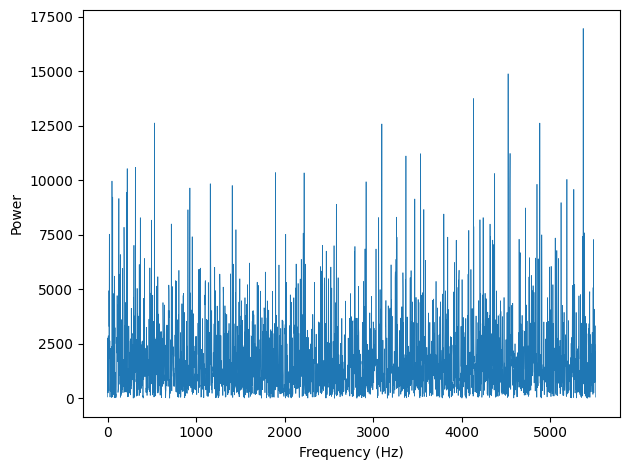

In [7]:
spectrum.plot_power(linewidth=0.5)
decorate(xlabel='Frequency (Hz)',
         ylabel='Power')

UU noise has the same power at all frequencies, on average, which we can confirm by looking at the normalized cumulative sum of power, which I call an integrated spectrum:

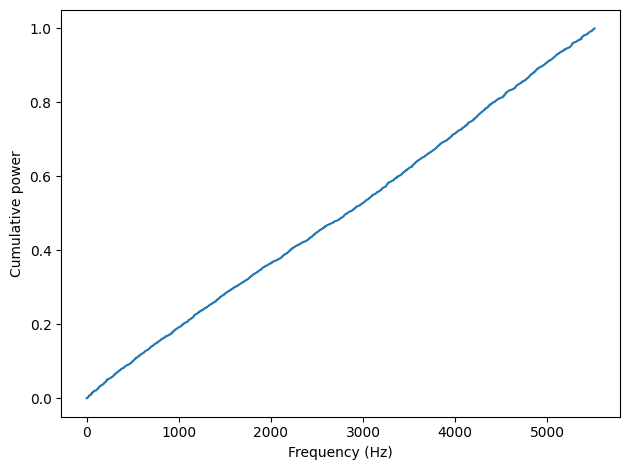

In [8]:
integ = spectrum.make_integrated_spectrum()
integ.plot_power()
decorate(xlabel='Frequency (Hz)',
         ylabel='Cumulative power')

A straight line in this figure indicates that UU noise has equal power at all frequencies, on average.  By analogy with light, noise with this property is called "white noise".

### Brownian noise

Brownian noise is generated by adding up a sequence of random steps.

In [9]:
from thinkdsp import BrownianNoise

signal = BrownianNoise()
wave = signal.make_wave(duration=0.5, framerate=11025)
wave.make_audio()

The sound is less bright, or more muffled, than white noise.

Here's what the wave looks like:

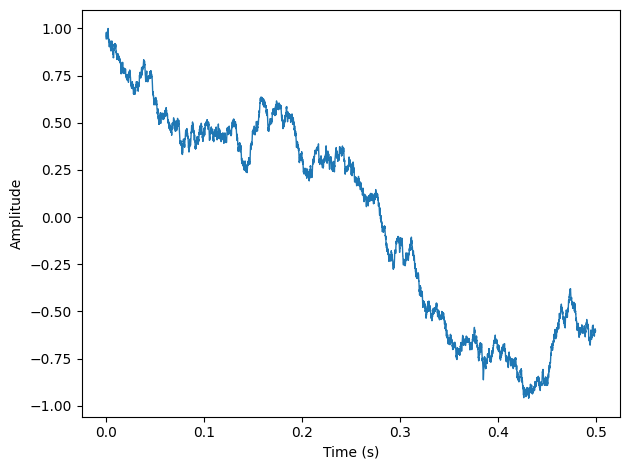

In [10]:
wave.plot(linewidth=1)
decorate(xlabel='Time (s)',
         ylabel='Amplitude')

Here's what the power spectrum looks like on a linear scale.

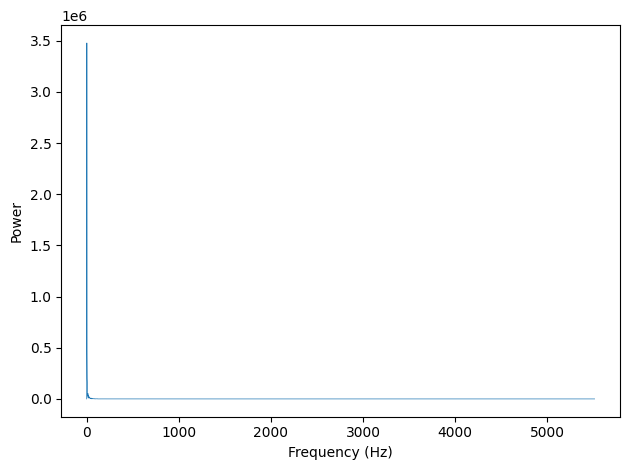

In [11]:
spectrum = wave.make_spectrum()
spectrum.plot_power(linewidth=0.5)
decorate(xlabel='Frequency (Hz)',
         ylabel='Power')

So much of the energy is at low frequencies, we can't even see the high frequencies.

We can get a better view by plotting the power spectrum on a log-log scale.

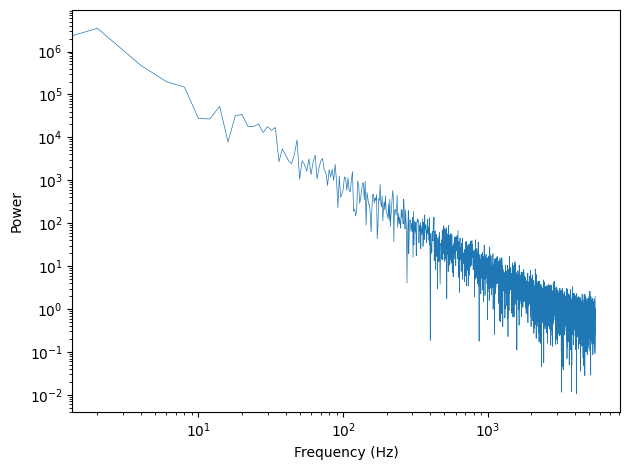

In [12]:
# The f=0 component is very small, so on a log scale
# it's very negative.  If we clobber it before plotting,
# we can see the rest of the spectrum more clearly.
spectrum.hs[0] = 0

spectrum.plot_power(linewidth=0.5)

loglog = dict(xscale='log', yscale='log')
decorate(xlabel='Frequency (Hz)',
         ylabel='Power',
         **loglog)

Now the relationship between power and frequency is clearer.  The slope of this line is approximately -2, which indicates that $P = K / f^2$, for some constant $K$.

In [13]:
signal =  BrownianNoise()
wave = signal.make_wave(duration=0.5, framerate=11025)
spectrum = wave.make_spectrum()
result = spectrum.estimate_slope()
result.slope

np.float64(-1.7846032211221778)

The estimated slope of the line is closer to -1.8 than -2, for reasons we'll see later.

### Pink noise

Pink noise is characterized by a parameter, $\beta$, usually between 0 and 2.  You can hear the differences below.

With $\beta=0$, we get white noise:

In [14]:
from thinkdsp import PinkNoise

signal = PinkNoise(beta=0)
wave = signal.make_wave(duration=0.5)
wave.make_audio()

With $\beta=1$, pink noise has the relationship $P = K / f$, which is why it is also called $1/f$ noise.

In [15]:
signal = PinkNoise(beta=1)
wave = signal.make_wave(duration=0.5)
wave.make_audio()

With $\beta=2$, we get Brownian (aka red) noise.

In [16]:
signal = PinkNoise(beta=2)
wave = signal.make_wave(duration=0.5)
wave.make_audio()

The following figure shows the power spectrums for white, pink, and red noise on a log-log scale.

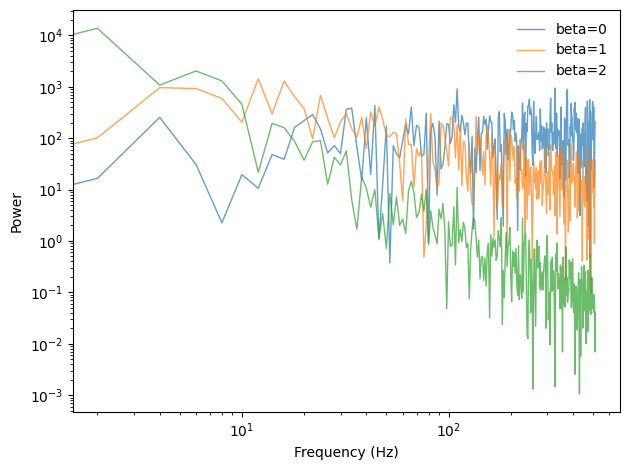

In [17]:
betas = [0, 1, 2]

for beta in betas:
    signal = PinkNoise(beta=beta)
    wave = signal.make_wave(duration=0.5, framerate=1024)
    spectrum = wave.make_spectrum()
    spectrum.hs[0] = 0
    label = f'beta={beta}'
    spectrum.plot_power(linewidth=1, alpha=0.7, label=label)

decorate(xlabel='Frequency (Hz)',
         ylabel='Power',
         **loglog)

### Uncorrelated Gaussian noise

An alternative to UU noise is uncorrelated Gaussian (UG noise).

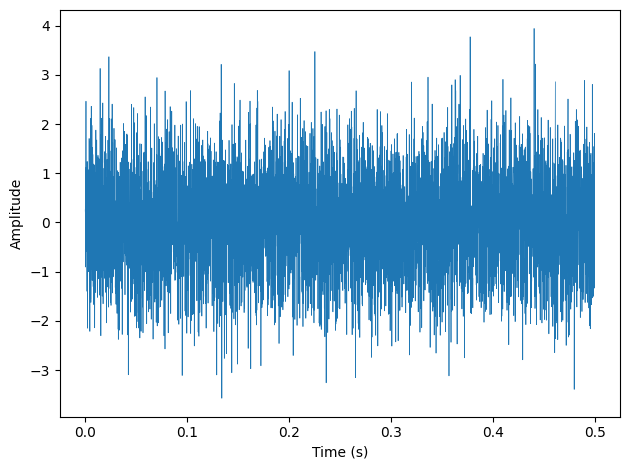

In [18]:
from thinkdsp import UncorrelatedGaussianNoise

signal = UncorrelatedGaussianNoise()
wave = signal.make_wave(duration=0.5, framerate=11025)
wave.plot(linewidth=0.5)
decorate(xlabel='Time (s)',
         ylabel='Amplitude')

The spectrum of UG noise is also UG noise.

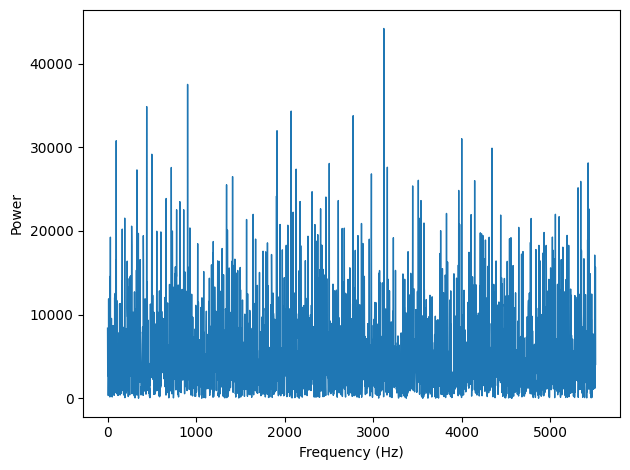

In [19]:
spectrum = wave.make_spectrum()
spectrum.plot_power(linewidth=1)
decorate(xlabel='Frequency (Hz)',
         ylabel='Power')

We can use a normal probability plot to test the distribution of the power spectrum.

In [20]:
def normal_prob_plot(sample, fit_color='0.8', **options):
    """Makes a normal probability plot with a fitted line.

    sample: sequence of numbers
    fit_color: color string for the fitted line
    options: passed along to Plot
    """
    n = len(sample)
    xs = np.random.normal(0, 1, n)
    xs.sort()

    ys = np.sort(sample)

    mean, std = np.mean(sample), np.std(sample)
    fit_ys = mean + std * xs
    plt.plot(xs, fit_ys, color='gray', alpha=0.5, label='model')

    plt.plot(xs, ys, **options)

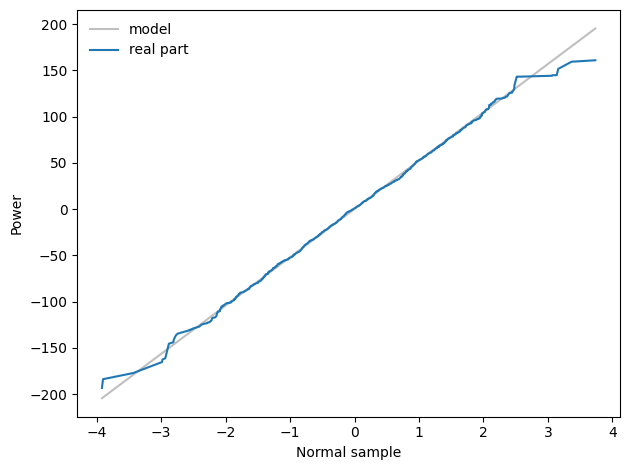

In [21]:
normal_prob_plot(spectrum.real, color='C0', label='real part')
decorate(xlabel='Normal sample',
         ylabel='Power')

A straight line on a normal probability plot indicates that the distribution of the real part of the spectrum is Gaussian.

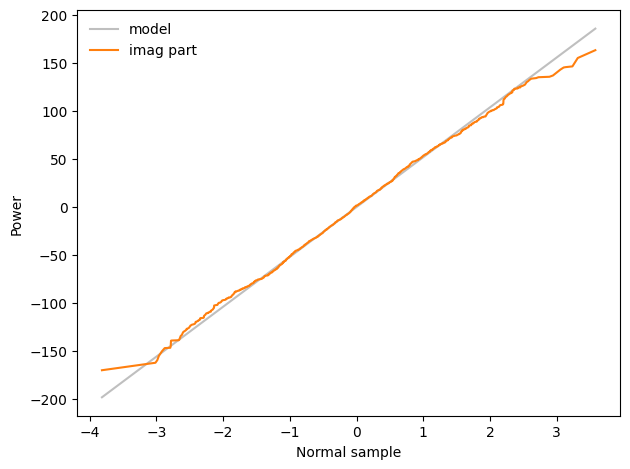

In [22]:
normal_prob_plot(spectrum.imag, color='C1', label='imag part')
decorate(xlabel='Normal sample',
         ylabel='Power')

And so is the imaginary part.

# Exercises

## Exercise 1

“A Soft Murmur” is a web site that plays a mixture of natural noise sources, including rain, waves, wind, etc. At http://asoftmurmur.com/about/ you can find their list of recordings, most of which are at http://freesound.org.
Download a few of these files and compute the spectrum of each signal. Does the power spectrum look like white noise, pink noise, or Brownian noise? How does the spectrum vary over time?

In [25]:
from thinkdsp import read_wave

wave = read_wave('ocean-waves.wav')
segment = wave.segment(start=1.5, duration=1.0)
segment.make_audio()

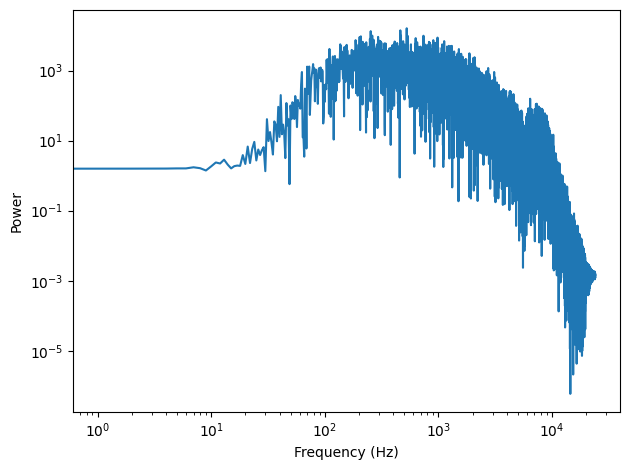

In [29]:
spectrum = segment.make_spectrum()
spectrum.plot_power()
decorate(xlabel='Frequency (Hz)', ylabel='Power', xscale='log', yscale='log')

## Exercise 2

In a noise signal, the mixture of frequencies changes over time. In the long run, we expect the power at all frequencies to be equal, but in any sample, the power at each frequency is random.
To estimate the long-term average power at each frequency, we can break a long signal into segments, compute the power spectrum for each segment, and then compute the average across the segments. You can read more about this algorithm at http://en.wikipedia.org/wiki/Bartlett's_method.

Implement Bartlett’s method and use it to estimate the power spectrum for a noise wave. Hint: look at the implementation of `make_spectrogram`.

In [30]:
from thinkdsp import Spectrum
import numpy as np

def bartlett_method(wave, seg_length=512):
    # make spectrogram and extract spectrums
    spectrogram = wave.make_spectrogram(seg_length)
    spectrums = spectrogram.spec_map.values()

    # extract all spectrum powers
    powers = [spectrum.power for spectrum in spectrums]

    # computer root mean power
    amp_phases = np.sqrt(sum(powers) / len(powers))  # result is array of complex numbers representing amplitude and phase for each frequency
    frequencies = next(iter(spectrums)).fs

    return Spectrum(amp_phases, frequencies, wave.framerate)

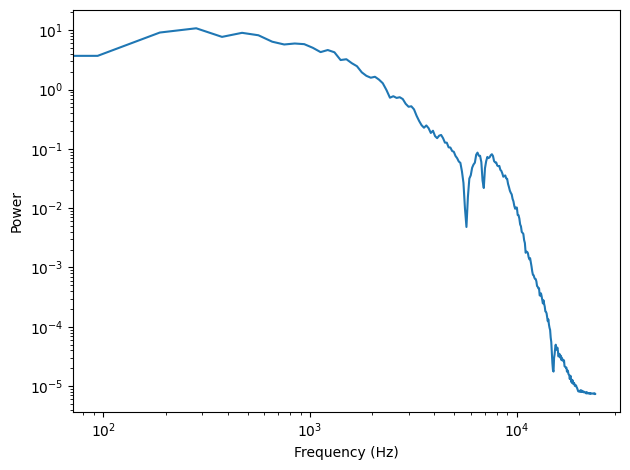

In [31]:
avg_spectrum = bartlett_method(segment)
avg_spectrum.plot_power()
decorate(xlabel='Frequency (Hz)', ylabel='Power', xscale='log', yscale='log')

## Exercise 3

At http://www.coindesk.com you can download the daily price of a BitCoin as a CSV file. Read this file and compute the spectrum of BitCoin prices as a function of time. Does it resemble white, pink, or Brownian noise?

In [1]:
import pandas as pd

df = pd.read_csv('BTC_USD_2013-10-01_2020-03-26-CoinDesk.csv')
df

,Currency,Date,Closing Price (USD),24h Open (USD),24h High (USD),24h Low (USD)
0,BTC,2013-10-01,123.654990,124.304660,124.751660,122.563490
1,BTC,2013-10-02,125.455000,123.654990,125.758500,123.633830
2,BTC,2013-10-03,108.584830,125.455000,125.665660,83.328330
3,BTC,2013-10-04,118.674660,108.584830,118.675000,107.058160
4,BTC,2013-10-05,121.338660,118.674660,121.936330,118.005660
...,...,...,...,...,...,...
2354,BTC,2020-03-22,5884.340133,6187.042146,6431.873162,5802.553402
2355,BTC,2020-03-23,6455.454688,5829.352511,6620.858253,5694.198299
2356,BTC,2020-03-24,6784.318011,6455.450650,6863.602196,6406.037439
2357,BTC,2020-03-25,6706.985089,6784.325204,6981.720386,6488.111885


In [3]:
frequencies = df['Closing Price (USD)']
times = df.index

RangeIndex(start=0, stop=2359, step=1)

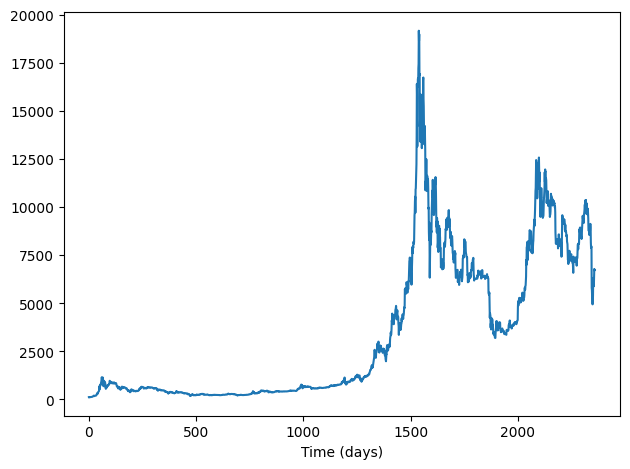

In [7]:
from thinkdsp import Wave, decorate

wave = Wave(frequencies, times, framerate=1)
wave.plot()
decorate(xlabel='Time (days)')

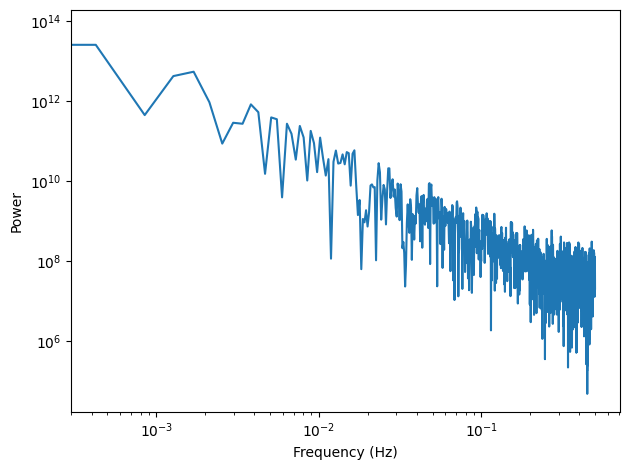

In [9]:
spectrum = wave.make_spectrum()
spectrum.plot_power()
decorate(xlabel='Frequency (Hz)', ylabel='Power', xscale='log', yscale='log')

## Exercise 4

A Geiger counter is a device that detects radiation. When an ionizing particle strikes the detector, it outputs a surge of current. The total output at a point in time can be modeled as uncorrelated Poisson (UP) noise, where each sample is a random quantity from a Poisson distribution, which corresponds to the number of particles detected during an interval.

Write a class called `UncorrelatedPoissonNoise` that inherits from `thinkdsp._Noise` and provides `evaluate`. It should use `np.random.poisson` to generate random values from a Poisson distribution. The parameter of this function, `lam`, is the average number of particles during each interval. You can use the attribute `amp` to specify `lam`. For example, if the `framerate` is 10 kHz and `amp` is 0.001, we expect about 10 “clicks” per second.

Generate about a second of UP noise and listen to it. For low values of `amp`, like 0.001, it should sound like a Geiger counter. For higher values it should sound like white noise. Compute and plot the power spectrum to see whether it looks like white noise.

In [11]:
from thinkdsp import Noise
import numpy as np

class UncorrelatedPoissonNoise(Noise):
    def evaluate(self, ts):
        return np.random.poisson(self.amp, len(ts))

In [13]:
amp = 0.001
duration = 1
framerate = 10000

signal = UncorrelatedPoissonNoise(amp)
wave = signal.make_wave(duration, framerate)
wave.make_audio()

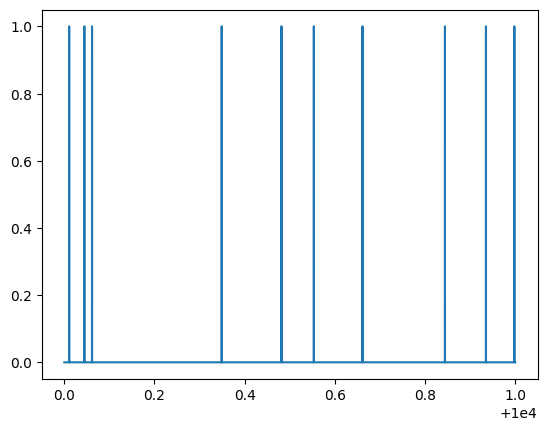

In [14]:
wave.plot()

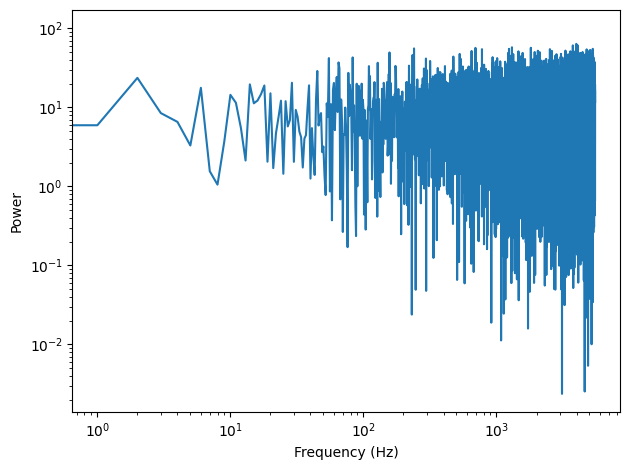

In [15]:
spectrum = wave.make_spectrum()
spectrum.plot_power()
decorate(xlabel='Frequency (Hz)', ylabel='Power', xscale='log', yscale='log')

In [16]:
amp = 1
framerate = 10000
duration = 1

signal = UncorrelatedPoissonNoise(amp)
wave = signal.make_wave(duration, framerate)
wave.make_audio()

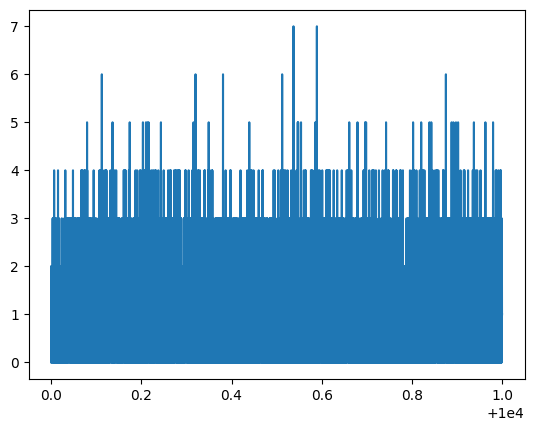

In [17]:
wave.plot()

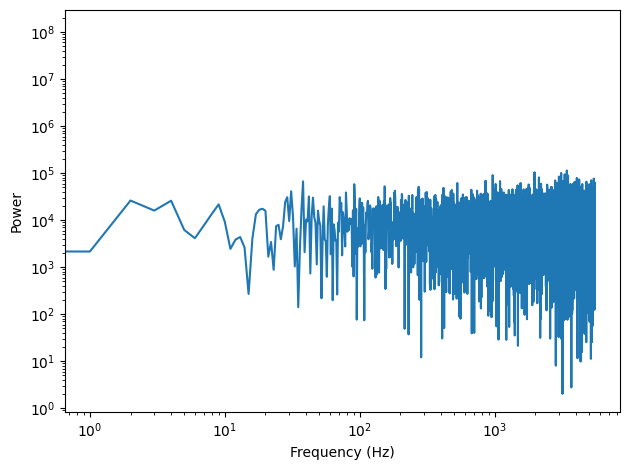

In [18]:
spectrum = wave.make_spectrum()
spectrum.plot_power()
decorate(xlabel='Frequency (Hz)', ylabel='Power', xscale='log', yscale='log')

# Glossary

- Noise: Signal that contains components at many frequencies. Lacks harmonic structure.
- Power: Square of amplitude. Conventionally used in the context of noise.
- Noise Qualities
  - Distribution: Set of possible values and their probabilities.
    - Uniform: Values range from -1 to 1, with equal probability
    - Gaussian: Values range from negative infinity to positive infinity, but values near 0 are most likely, with probability that drops off according to the Guassian/"bell" curve.
  - Correlation: Is each value in the signal independent of the others, or are there dependencies between them?
    - Uniform: Each value is independent of the others.
    - Brownian: Each value is the sum of the previous value and a random "step".
      - If a value is high, we expect it to stay high.
      - If a value is low, we expect it to stay low.
  - Relationship between Power and Frequency
    - Uniform: Power at all Frequencies is drawn from same distribution. Average Power is same for all Frequencies.
    - Pink: Power is inversely related to Frequency. Power at frequency `f` is drawn from a distribution whose *mean* is proportional to `1/f`.
- Integrated Spectrum: A function of Frequency, `f`, that shows the cumulative Power in the spectrum up to `f`.
- White Noise: Equal Power at all Frequencies. Analogy with light - equal mixture of light at all visible Frequencies is white.
- Brownian Noise: Each value is the sum of the previous value and a random "step". Analogy with Brownian motion - a particle suspended in fluid moves apparently at random, due to unseen interactions with the fluid. Also called Red Noise, since most of the power will be at low Frequencies, which corresponds to red.